In [ ]:
import numpy as np
import nibabel as nib
from nilearn import datasets
import os.path as op
import os
import pandas as pd
from brainspace.gradient import GradientMaps
from brainspace.utils.parcellation import map_to_labels
import matplotlib.pyplot as plt

from utils import get_basic_mask
mask, labeling_noParcel = get_basic_mask()
N_vertices = len(np.where(mask==True)[0])

bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk'
bids_folder_orig = '/mnt_03/ds-dnumrisk' 

source_folder = op.join(bids_folder,'derivatives','correlation_matrices.tryNoHalo')
sub='all'
ses=1
task='magjudge'


[get_dataset_dir] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


In [ ]:
# get average CM: done in shell via tmux, takes some time!

confspec='36Pscrub3'

subList = [f[4:6] for f in os.listdir(bids_folder_orig) if f[0:4] == 'sub-' and len(f) == 6]
matrix_zeros = np.zeros((N_vertices, N_vertices))
av_cm = matrix_zeros.copy()
error_list = []
for sub in subList:
    try:
        correlation_matrix = np.load(op.join(source_folder,
            f'sub-{sub}_ses-{ses}_task-{task}_confspec-{confspec}_CM-unfiltered.npy'))
        av_cm += np.arctan(correlation_matrix)  # Fisher Z-transformation
        print(f'Subject {sub} added' )
    except Exception as e:
        print(f'Subject {sub} failed')
        error_list.append(sub)

av_cm = av_cm / len(subList)
av_cm_transf = np.tan(av_cm)  # Sanity check: diagonal should be 1!
np.save(op.join(source_folder,f'cm_av_ses-{ses}_fsav5_unfiltered_confspec-{confspec}.npy'), av_cm_transf)

In [ ]:
# load in average CM : done in notebook

av_cm_transf = np.load(op.join(source_folder,f'cm_av_ses-{ses}_fsav5_unfiltered_confspec-{confspec}.npy'))

from brainspace.gradient import GradientMaps
from brainspace.utils.parcellation import map_to_labels

n_components = 10
gm = GradientMaps(n_components=n_components) # , alignment='procrustes'
gm.fit(av_cm_transf) # ,reference=g_ref

/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/brainspace-0.1.4-py3.10.egg/brainspace/gradient/embedding.py:70: UserWarning: Affinity is not symmetric. Making symmetric.
  warnings.warn('Affinity is not symmetric. Making symmetric.')


GradientMaps()

In [11]:
av_cm_transf.shape

(18715, 18715)

In [13]:
g_ref[:,mask].shape

(10, 18715)

In [33]:
# fit aligned to Margulies16

confspec='oldConfounds' #'36Pscrub3'
av_cm_transf = np.load(op.join(source_folder,f'cm_av_ses-{ses}_fsav5_unfiltered_confspec-{confspec}.npy'))

alig_marg16 = True
g_ref = np.load(op.join(bids_folder_orig,'derivatives', 'gradients','reference_gradients_margulies16_space-fsaverage5_N-10.npy'))
g_ref_fil = g_ref[:,mask].T  # np.shape(g_ref) = (10,20484)

from brainspace.gradient import GradientMaps
from brainspace.utils.parcellation import map_to_labels
n_components = 10
gm = GradientMaps(n_components=n_components, alignment='procrustes' ) 
gm.fit(av_cm_transf ,reference=g_ref_fil)

/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/brainspace-0.1.4-py3.10.egg/brainspace/gradient/embedding.py:70: UserWarning: Affinity is not symmetric. Making symmetric.
  warnings.warn('Affinity is not symmetric. Making symmetric.')


GradientMaps(alignment='procrustes')

In [34]:
sub = 'All'
target_dir = op.join(bids_folder,'derivatives','gradients.tryNoHalo', f'sub-{sub}')
if not op.exists(target_dir):
    os.makedirs(target_dir)
    
np.save(op.join(target_dir,f'sub-{sub}_lambdas_space-fsaverag5_confspec-{confspec}.npy'), gm.lambdas_) # save all together
gm_= gm.gradients_.T 
grad = [None] * n_components
for i, g in enumerate(gm_): # gm.gradients_.T
    grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)
np.save(op.join(target_dir,f'sub-{sub}_gradients_space-fsaverag5_confspec-{confspec}.npy'), grad) # save all together

if alig_marg16: 
    gm_ = gm.aligned_.T
    grad = [None] * n_components
    for i, g in enumerate(gm_): # gm.gradients_.T
        grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)
    np.save(op.join(target_dir,f'sub-{sub}_g-aligned-margulies16_space-fsaverag5_confspec-{confspec}.npy'), grad) # save all together    


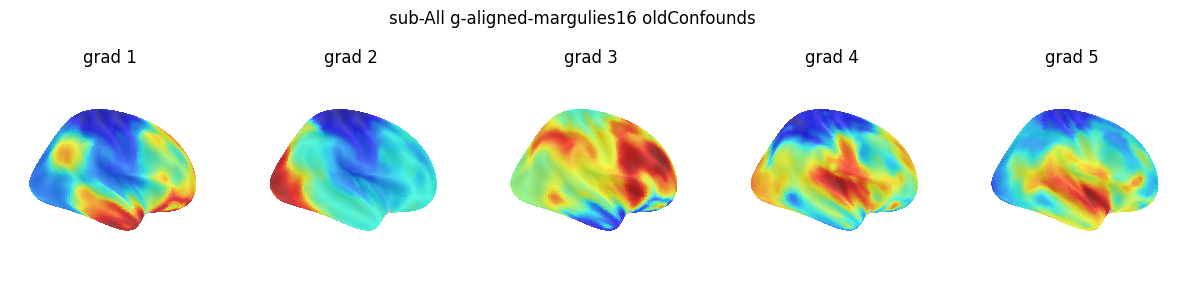

In [35]:
from utils import plot_grads

#confspec =  '36Pscrub3' # 
target_dir = op.join(bids_folder,'derivatives','gradients.tryNoHalo', f'sub-{sub}')
spec = 'g-aligned-margulies16' # 'gradients
grad = np.load(op.join(target_dir,f'sub-{sub}_{spec}_space-fsaverag5_confspec-{confspec}.npy'))  
plot_grads(grad, sub, spec=spec, confspec=confspec)

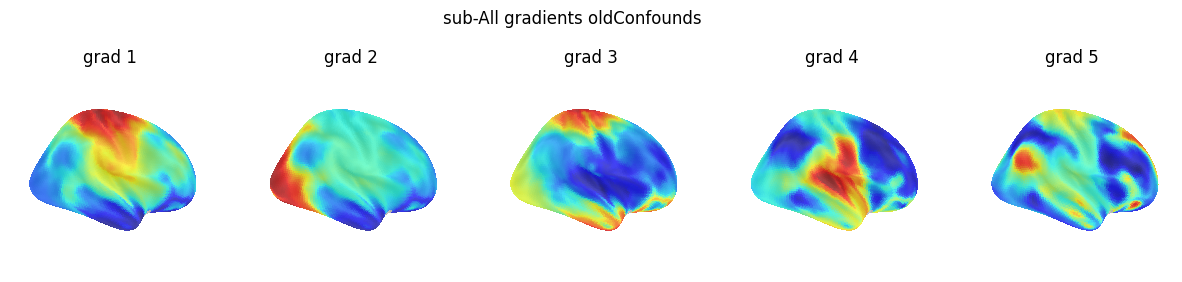

In [36]:
from utils import plot_grads

#confspec = '36Pscrub3' # 
target_dir = op.join(bids_folder,'derivatives','gradients.tryNoHalo', f'sub-{sub}')
spec = 'gradients'
grad = np.load(op.join(target_dir,f'sub-{sub}_{spec}_space-fsaverag5_confspec-{confspec}.npy'))  
plot_grads(grad, sub, spec=spec, confspec=confspec)